Importing Libraries

In [16]:
##%pip install --upgrade --force-reinstall numpy

In [17]:
# Import necessary libraries

import requests
import astropy
import numpy as np
import urllib.request
import json
import geocoder
import webbrowser
import time
import geopy
import matplotlib.pyplot as plt

Fetching ISS (Two line element) TLE data

In [35]:

response = urllib.request.urlopen('http://api.open-notify.org/iss-now.json')
result = json.loads(response.read())
print(result)


{'timestamp': 1753377382, 'iss_position': {'longitude': '-67.4062', 'latitude': '16.2322'}, 'message': 'success'}


In [36]:
from datetime import timedelta, datetime
from geopy.geocoders import Nominatim
import pytz
ist = pytz.timezone('Asia/Kolkata')

# Initialize Nominatim API
geolocator = Nominatim(user_agent="my_geopy_app")
name = str(input("Enter a location name: "))
location = geolocator.geocode(name)
print("\nLocation Coordinates:")
print(f"Latitude: {location.latitude}")
print(f"Longitude: {location.longitude}\n")


latitude, longitude = location.latitude, location.longitude
from skyfield.api import EarthSatellite, Topos, load

# Example TLE lines
line1 = '1 25544U 98067A   25204.16864096  .00010724  00000+0  19544-3 0  9992'
line2 = '2 25544  51.6344 128.7280 0002115 106.2807 253.8414 15.50025731520740'
satellite = EarthSatellite(line1, line2, 'ISS (ZARYA)')

# Load timescale and observer location
ts = load.timescale()
observer = Topos(latitude_degrees=latitude, longitude_degrees=longitude)
t0 = ts.now()
t1 = ts.utc(t0.utc_datetime() + timedelta(days=0.5))  # Next 12 hours

# Find events (rise, culmination, set)
times, events = satellite.find_events(observer, t0, t1, altitude_degrees=0.0) 

event_names = ['rise', 'culminate', 'set']
print("Next ISS Passes:\n")
group = []
for ti, event in zip(times, events):
    utc_dt = ti.utc_datetime().replace(tzinfo=pytz.utc)
    ist_dt = utc_dt.astimezone(ist)
    group.append(f"{event_names[event].capitalize()}: {ist_dt.strftime('%Y-%m-%d %H:%M:%S IST')}")
    if event == 2:  # 'set' event
        print("\n".join(group))
        print("-" * 40)
        group = []


Location Coordinates:
Latitude: 21.2380912
Longitude: 81.6336993

Next ISS Passes:

Rise: 2025-07-24 23:16:30 IST
Culminate: 2025-07-24 23:21:37 IST
Set: 2025-07-24 23:26:44 IST
----------------------------------------


In [20]:
from mpl_toolkits.basemap import Basemap

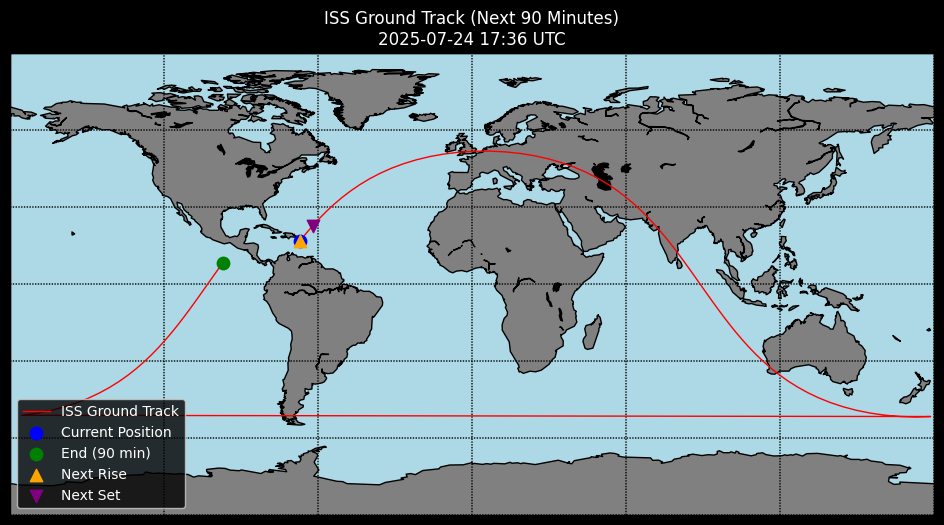

In [42]:
# ...existing code...
plt.figure(figsize=(12, 6))
m = Basemap(projection='cyl', llcrnrlat=-90, urcrnrlat=90,
            llcrnrlon=-180, urcrnrlon=180, resolution='c')
m.drawcoastlines()
m.fillcontinents(color='grey')
m.drawparallels(np.arange(-90., 91., 30.))
m.drawmeridians(np.arange(-180., 181., 60.))
m.bluemarble()
m.drawmapboundary(fill_color='lightblue')

# ISS ground track
m.plot(lons, lats, color='red', linewidth=1, label='ISS Ground Track')

# Mark current position (first point)
m.scatter(lons[0], lats[0], color='blue', s=80, label='Current Position', zorder=5)

# Mark end position (last point)
m.scatter(lons[-1], lats[-1], color='green', s=80, label='End (90 min)', zorder=5)

# Mark next rise and set points if available
if 'times' in locals() and 'events' in locals():
    # Find next rise and set events
    rise_idx = None
    set_idx = None
    for idx, event in enumerate(events):
        if event == 0 and rise_idx is None:  # rise
            rise_idx = idx
        if event == 2 and set_idx is None:   # set
            set_idx = idx
    if rise_idx is not None:
        rise_time = times[rise_idx]
        rise_geocentric = satellite.at(rise_time)
        rise_subpoint = rise_geocentric.subpoint()
        m.scatter(rise_subpoint.longitude.degrees, rise_subpoint.latitude.degrees,
                  color='orange', s=80, marker='^', label='Next Rise', zorder=5)
    if set_idx is not None:
        set_time = times[set_idx]
        set_geocentric = satellite.at(set_time)
        set_subpoint = set_geocentric.subpoint()
        m.scatter(set_subpoint.longitude.degrees, set_subpoint.latitude.degrees,
                  color='purple', s=80, marker='v', label='Next Set', zorder=5)

# Title with current date/time
from datetime import datetime
plt.title(f"ISS Ground Track (Next 90 Minutes)\n{datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}")
plt.legend(loc='lower left')
plt.show()
# ...existing code...